# pandas III: gráficos con matplotlib

[![Abrir en Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gf0657-programacionsig/2026-ii/blob/main/contenidos/iii-analisis-visualizacion-datos/14-pandas-graficos-matplotlib.ipynb)

## Trabajo previo

### Lecturas

Antes de la clase, revise las siguientes lecturas, en inglés. El capítulo de McKinney presenta los gráficos de pandas y de matplotlib con el mismo enfoque de este cuaderno; la guía de inicio rápido de matplotlib explica las partes de una figura; el artículo de Hunter es la presentación original de la biblioteca y basta con leer su introducción.

McKinney, W. (2022). Plotting and visualization. En *Python for data analysis: Data wrangling with pandas, NumPy, and Jupyter* (3.ª ed.). O'Reilly Media. https://wesmckinney.com/book/plotting-and-visualization
\
\
The Matplotlib Development Team. (s. f.). Quick start guide. En *Matplotlib documentation*. Recuperado el 26 de setiembre de 2026, de https://matplotlib.org/stable/users/explain/quick_start.html
\
\
Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, *9*(3), 90-95. https://doi.org/10.1109/MCSE.2007.55

### Otros recursos

El capítulo [Chart visualization](https://pandas.pydata.org/docs/user_guide/visualization.html) de la guía del usuario de pandas documenta el método `plot()`; la galería [Plot types](https://matplotlib.org/stable/plot_types/index.html) de matplotlib muestra, con código, cada tipo de gráfico. El libro [Fundamentals of data visualization](https://clauswilke.com/dataviz/), de Claus Wilke, es una referencia excelente, gratuita en línea, sobre cómo elegir y diseñar un gráfico.

## Introducción

Este cuaderno es la tercera parte de la serie *pandas*. La [parte I](https://gf0657-programacionsig.github.io/2026-ii/pandas-series-dataframes/) presentó las Series y los DataFrames, y la [parte II](https://gf0657-programacionsig.github.io/2026-ii/pandas-agrupacion-uniones/), la agrupación, las uniones y los datos faltantes. Todo lo hecho hasta ahora produce tablas. Esta parte produce **gráficos**: la forma más eficaz de descubrir patrones en los datos y de comunicarlos.

Un gráfico cumple dos funciones distintas. Durante el análisis, sirve para **explorar**: un histograma revela en segundos si una variable es simétrica o tiene valores extremos, y un gráfico de dispersión muestra si dos variables se relacionan. Al final, sirve para **comunicar**: un gráfico bien diseñado, con título, etiquetas y unidades, transmite un resultado sin necesidad de leer una tabla. Este cuaderno cubre ambas funciones: cómo producir un gráfico en una línea, para explorar, y cómo refinarlo, para comunicar.

Las herramientas son dos, estrechamente unidas. [matplotlib](https://matplotlib.org/) es la biblioteca fundamental de visualización de Python, sobre la que se construyen muchas otras (entre ellas, las de geopandas para mapas). pandas incorpora un método `plot()` que produce gráficos de matplotlib directamente a partir de Series y DataFrames, con muy poco código. La estrategia del cuaderno es usar pandas para dibujar y matplotlib para refinar. Al final se presentan la estructura de un cuaderno de análisis de datos, que es la de la tarea 2, y el uso de los asistentes de IA para generar y verificar gráficos.

El hilo conductor siguen siendo los datos de la [Estimación de Población y Vivienda 2022](https://inec.cr/) del Instituto Nacional de Estadística y Censos (INEC), con la serie de censos desde 1864 y los casos de COVID-19 por cantón del Ministerio de Salud, preparados como en la parte II.

Como todos los cuadernos del curso, puede ejecutarse en la nube, con la insignia "Abrir en Google Colab", o localmente, en [Visual Studio Code](https://gf0657-programacionsig.github.io/2026-ii/vscode/) con el ambiente `geopython` como kernel. El archivo `.ipynb` puede descargarse con el botón de descarga (ícono de flecha hacia abajo) en la parte superior de la página del cuaderno, en el sitio web del curso.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Direcciones de los directorios de datos en el repositorio del curso
DATOS = "https://raw.githubusercontent.com/gf0657-programacionsig/2026-ii/main/datos/inec"
DATOS_SALUD = "https://raw.githubusercontent.com/gf0657-programacionsig/2026-ii/main/datos/ministerio-salud"

# Niveles de la división territorial (INEC, 2022)
provincias = pd.read_csv(DATOS + "/provincias-2022.csv")
cantones = pd.read_csv(DATOS + "/cantones-2022.csv")
distritos = pd.read_csv(DATOS + "/distritos-2022.csv")

# Población de Costa Rica en los censos, 1864-2022 (cuadro 1 del Excel del INEC)
censos = pd.read_excel(
    DATOS + "/reResultadosEstimacionPoblacionVivienda2022_3.xlsx",
    sheet_name="1", skiprows=6, nrows=11, header=None,
    names=["anio", "poblacion", "hombres", "mujeres", "tasa_crecimiento"],
    na_values="-"
)

# Casos positivos de COVID-19 por cantón al 30-05-2022, unidos con la población (como en la parte II)
covid = pd.read_csv(
    DATOS_SALUD + "/05_30_22_CSV_POSITIVOS.csv",
    sep=";", encoding="cp1252", usecols=["cod_canton", "30/05/2022"]
).dropna()
covid = covid.rename(columns={"cod_canton": "codigo_canton", "30/05/2022": "positivos"}).astype(int)
cantones_covid = cantones.merge(covid, on="codigo_canton", how="left")
cantones_covid["tasa_100k"] = (cantones_covid["positivos"] / cantones_covid["poblacion"] * 100000).round(0)

# Colores del cuaderno: el azul por defecto de matplotlib y un naranja que se distingue de él
# incluso para personas con daltonismo
AZUL = "#1F77B4"
NARANJA = "#D97B1B"

print(provincias.shape, cantones.shape, distritos.shape, censos.shape, cantones_covid.shape)

(7, 14) (82, 16) (487, 17) (11, 5) (82, 18)


## Un primer gráfico

El método `plot()` de un DataFrame produce un gráfico a partir de sus columnas. Los argumentos `x` y `y` indican cuáles, y `kind`, el tipo de gráfico. Un gráfico de barras con la población de las provincias:

<Axes: xlabel='provincia'>

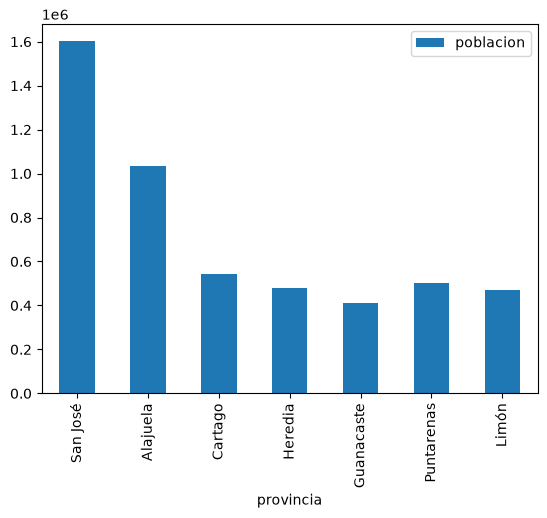

In [2]:
# Población de las provincias: primer intento
provincias.plot(x="provincia", y="poblacion", kind="bar")

Una sola línea produjo un gráfico completo, con las provincias en el eje horizontal y la población en el vertical. Para explorar, basta. Para comunicar, tiene varios problemas:

- No tiene **título**, y las etiquetas de los ejes son los nombres de las columnas (`provincia`, en minúscula) o no existen (el eje vertical no dice qué mide ni en qué unidades).
- El eje vertical usa **notación científica** (`1e6`), difícil de leer.
- Las provincias aparecen en el orden del archivo, no por población, y sus nombres están girados.
- La **leyenda** es innecesaria: solo hay una variable.
- Antes del gráfico se imprime una línea con `<Axes: ...>`: es el objeto que retorna `plot()`, y da una pista sobre cómo funciona matplotlib.

Para corregir cada problema hay que entender de qué se compone un gráfico.

## Anatomía de una figura

En matplotlib, todo gráfico vive dentro de una **figura** (`Figure`): el lienzo completo, que puede contener uno o varios gráficos. Cada gráfico es un objeto **`Axes`**, que en español se llamaría "ejes" o "subgráfico": el área con los datos, sus dos ejes (`Axis`, en singular: el horizontal y el vertical), el título, las etiquetas, las marcas (*ticks*), la leyenda y la cuadrícula. La figura 1 identifica esas partes, con el nombre del método que las modifica.

<figure style="text-align: center;">
  <img
    src="https://raw.githubusercontent.com/gf0657-programacionsig/2026-ii/main/contenidos/iii-analisis-visualizacion-datos/img/anatomia-figura.png"
    alt="Gráfico de barras de la población por sexo de las provincias de Costa Rica con anotaciones que señalan la figura, los ejes (Axes), el título, las etiquetas de los ejes, las marcas, la cuadrícula, la leyenda y las barras"
    style="max-width: 760px; width: 100%;"
  >
  <figcaption><strong>Figura 1</strong>. Partes de una figura de matplotlib y métodos de <code>Axes</code> que las modifican. Datos del INEC (2023). Elaboración propia.</figcaption>
</figure>

El patrón de trabajo del cuaderno se desprende de esa estructura, en tres pasos:

1. `plt.subplots()` crea una figura y sus ejes, y los retorna en dos variables, por convención `fig` y `ax`. El argumento `figsize` es el tamaño en pulgadas (ancho, alto).
2. `plot()` de pandas dibuja los datos **en esos ejes**, con el argumento `ax=ax`.
3. Los métodos de `ax` (`set_title()`, `set_xlabel()`, `set_ylabel()`...) refinan el gráfico, y `plt.show()` lo despliega.

El primer gráfico, con ese patrón y sus problemas corregidos:

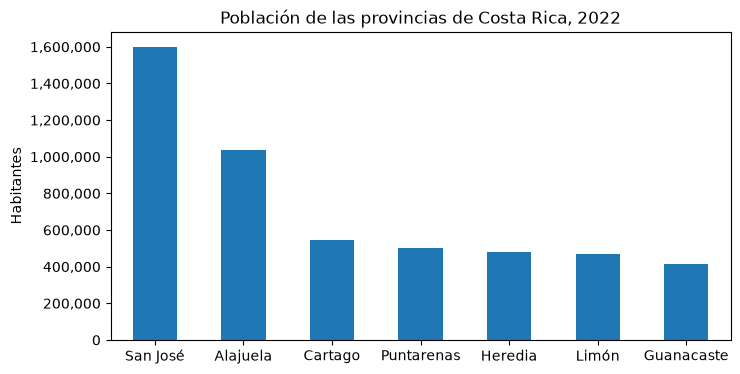

In [3]:
from matplotlib.ticker import StrMethodFormatter

# 1. Figura y ejes
fig, ax = plt.subplots(figsize=(8, 4))

# 2. Datos: provincias ordenadas por población, sin leyenda
provincias.sort_values("poblacion", ascending=False).plot(
    x="provincia", y="poblacion", kind="bar", ax=ax, color=AZUL, legend=False
)

# 3. Refinamiento
ax.set_title("Población de las provincias de Costa Rica, 2022")
ax.set_xlabel("")  # el nombre de la provincia se explica solo
ax.set_ylabel("Habitantes")
ax.tick_params(axis="x", rotation=0)  # nombres horizontales
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))  # separador de miles en vez de 1e6

plt.show()

Dos detalles:

- `StrMethodFormatter("{x:,.0f}")` aplica a cada marca del eje el formato de las hileras de Python visto en la serie *Fundamentos de Python*: separador de miles y cero decimales. Es la forma de evitar la notación científica.
- `plt.show()` despliega la figura y, de paso, evita la línea `<Axes: ...>`. En un cuaderno de notas la figura se muestra igual sin él, pero es una buena costumbre terminar con `plt.show()` cada celda que produce un gráfico.

Este patrón (`subplots()`, `plot(ax=ax)`, métodos de `ax`, `show()`) se repite en todos los gráficos del cuaderno. Lo que cambia es el tipo de gráfico, y el tipo depende de la pregunta que se quiere responder.

## Tipos de gráficos

### Barras: comparar categorías

Un [gráfico de barras](https://es.wikipedia.org/wiki/Diagrama_de_barras) compara una **magnitud entre categorías**: la población de cada provincia, la cantidad de cantones de cada provincia. La longitud de cada barra es el valor, por lo que el eje de los valores debe empezar en cero. Las barras horizontales (`kind="barh"`) son preferibles cuando las categorías tienen nombres largos o son muchas, como los diez cantones más poblados. Note que se ordenan de forma **ascendente**, porque `barh()` dibuja la primera fila abajo, y que `bar_label()` escribe el valor al final de cada barra:

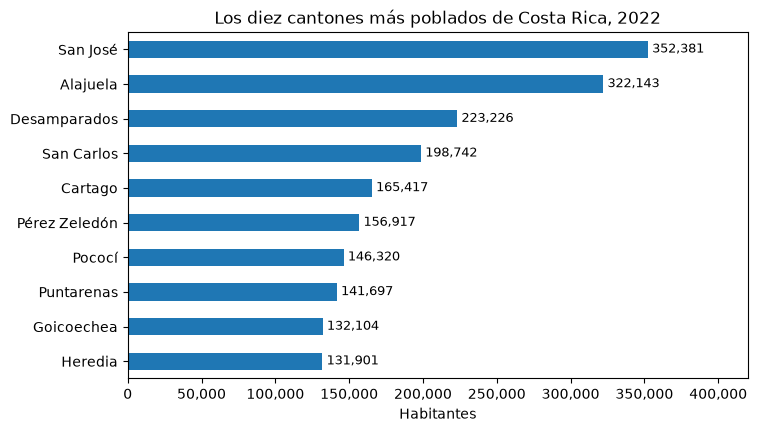

In [4]:
# Los diez cantones más poblados, en barras horizontales
top_10 = cantones.sort_values("poblacion", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 4.5))

top_10.sort_values("poblacion").plot(
    x="canton", y="poblacion", kind="barh", ax=ax, color=AZUL, legend=False
)

ax.set_title("Los diez cantones más poblados de Costa Rica, 2022")
ax.set_xlabel("Habitantes")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.bar_label(ax.containers[0], fmt="{:,.0f}", padding=3, fontsize=9)  # valor al final de cada barra
ax.set_xlim(0, 420000)  # espacio para las etiquetas

plt.show()

`plot()` también funciona con una **Series**, en cuyo caso el índice va al eje de categorías. Eso lo hace ideal para graficar el resultado de `value_counts()` o de una agrupación, sin `reset_index()`:

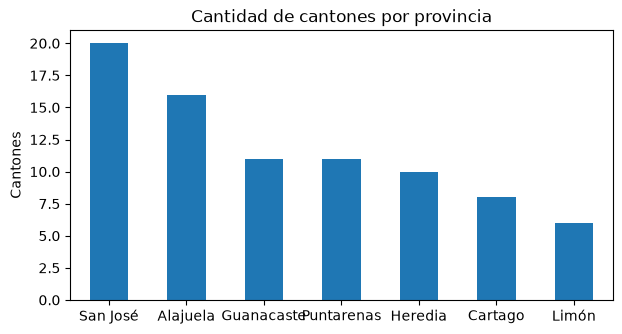

In [5]:
# Cantidad de cantones por provincia: una Series (value_counts) graficada directamente
fig, ax = plt.subplots(figsize=(7, 3.5))

cantones["provincia"].value_counts().plot(kind="bar", ax=ax, color=AZUL)

ax.set_title("Cantidad de cantones por provincia")
ax.set_xlabel("")
ax.set_ylabel("Cantones")
ax.tick_params(axis="x", rotation=0)

plt.show()

Cuando se comparan **dos o más series** en las mismas categorías, `y` recibe una lista de columnas y pandas dibuja **barras agrupadas**, con una leyenda que las distingue. Como el color ahora codifica la serie, se eligen colores que se diferencien bien y se nombran las series en la leyenda con `label`:

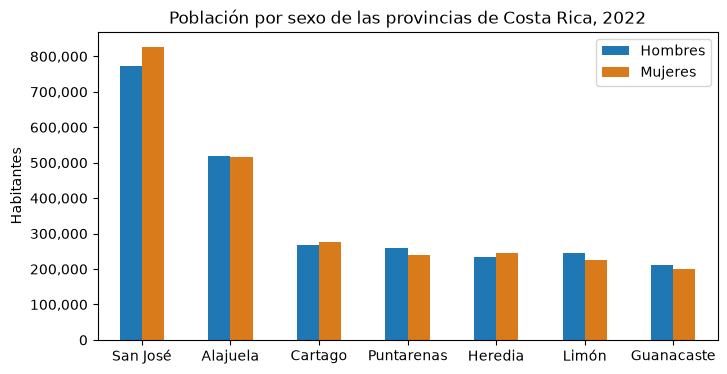

In [6]:
# Población por sexo de cada provincia: barras agrupadas
fig, ax = plt.subplots(figsize=(8, 4))

provincias.sort_values("poblacion", ascending=False).plot(
    x="provincia", y=["hombres", "mujeres"], kind="bar", ax=ax,
    color=[AZUL, NARANJA], label=["Hombres", "Mujeres"]
)

ax.set_title("Población por sexo de las provincias de Costa Rica, 2022")
ax.set_xlabel("")
ax.set_ylabel("Habitantes")
ax.tick_params(axis="x", rotation=0)
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.legend(title="")

plt.show()

El gráfico muestra que las mujeres son mayoría solo en las provincias del Valle Central (San José, Cartago y Heredia), y los hombres en las costeras y fronterizas. Con `stacked=True`, las barras se **apilan** en lugar de agruparse: útil cuando interesa el total además de las partes.

### Líneas: cambio en el tiempo

Un [gráfico de líneas](https://es.wikipedia.org/wiki/Gr%C3%A1fico_de_l%C3%ADneas) muestra cómo **cambia una variable a lo largo del tiempo** (o de otra variable continua y ordenada). Los puntos se unen con una línea porque el orden tiene sentido: cada valor sigue al anterior. Es el gráfico natural para la serie de censos:

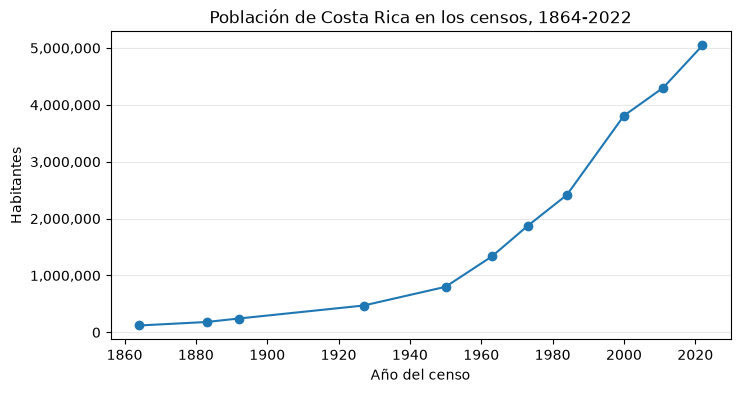

In [7]:
# Población de Costa Rica en los censos, 1864-2022
fig, ax = plt.subplots(figsize=(8, 4))

censos.plot(x="anio", y="poblacion", kind="line", ax=ax, color=AZUL, marker="o", legend=False)

ax.set_title("Población de Costa Rica en los censos, 1864-2022")
ax.set_xlabel("Año del censo")
ax.set_ylabel("Habitantes")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="y", alpha=0.3)  # cuadrícula horizontal, tenue

plt.show()

El eje horizontal es numérico: los censos no son equidistantes (hay 19 años entre 1864 y 1883, y 11 entre 2011 y 2022), y la línea respeta esas distancias. Los marcadores (`marker="o"`) señalan los años en que sí hay datos. La curva muestra el crecimiento acelerado de la segunda mitad del siglo XX; la tasa de crecimiento lo hace explícito, y como falta para el primer censo (el `NaN` de la parte II), la línea empieza en 1883:

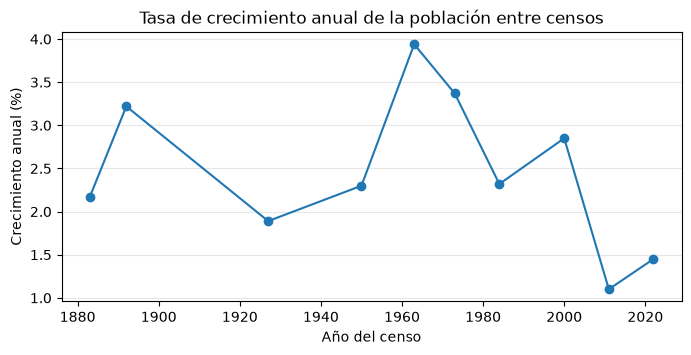

In [8]:
# Tasa de crecimiento anual entre censos
fig, ax = plt.subplots(figsize=(8, 3.5))

censos.plot(x="anio", y="tasa_crecimiento", kind="line", ax=ax, color=AZUL, marker="o", legend=False)

ax.set_title("Tasa de crecimiento anual de la población entre censos")
ax.set_xlabel("Año del censo")
ax.set_ylabel("Crecimiento anual (%)")
ax.grid(axis="y", alpha=0.3)

plt.show()

### Histogramas: la distribución de una variable

Un [histograma](https://es.wikipedia.org/wiki/Histograma) muestra la **distribución de una variable numérica**: divide su rango en intervalos (*bins*) y cuenta cuántas observaciones caen en cada uno. Responde preguntas que una tabla no responde de un vistazo: ¿los valores se concentran o se dispersan?, ¿la distribución es simétrica?, ¿hay valores extremos? Aquí se grafica una Series, la población de los 487 distritos:

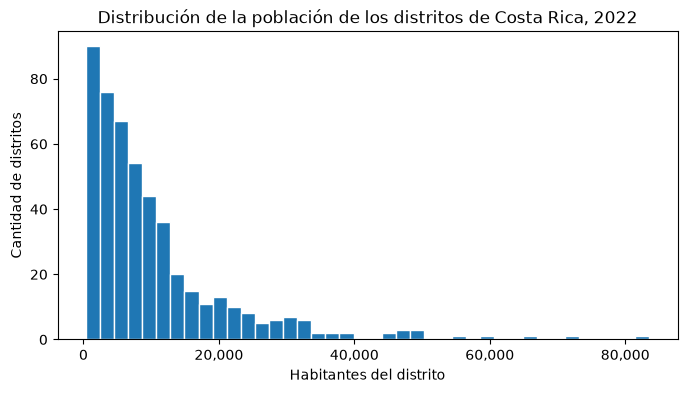

In [9]:
# Distribución de la población de los distritos
fig, ax = plt.subplots(figsize=(8, 4))

distritos["poblacion"].plot(kind="hist", bins=40, ax=ax, color=AZUL, edgecolor="white")

ax.set_title("Distribución de la población de los distritos de Costa Rica, 2022")
ax.set_xlabel("Habitantes del distrito")
ax.set_ylabel("Cantidad de distritos")
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

plt.show()

La distribución es muy **asimétrica**: la mayoría de los distritos tiene menos de 10 000 habitantes y unos pocos superan los 50 000. Es una forma frecuente en los datos geográficos (poblaciones, áreas, precipitaciones) y explica por qué el promedio (10 358 habitantes) es bastante mayor que la mediana (7056): los pocos distritos grandes lo elevan. El argumento `bins` controla la cantidad de intervalos: pocos esconden detalles; demasiados producen ruido. Conviene probar dos o tres valores.

### Dispersión: la relación entre dos variables

Un [gráfico de dispersión](https://es.wikipedia.org/wiki/Diagrama_de_dispersi%C3%B3n) muestra la **relación entre dos variables numéricas**: cada observación es un punto, con una variable en cada eje. ¿Los cantones más densamente poblados tuvieron tasas más altas de COVID-19? Cada punto es un cantón:

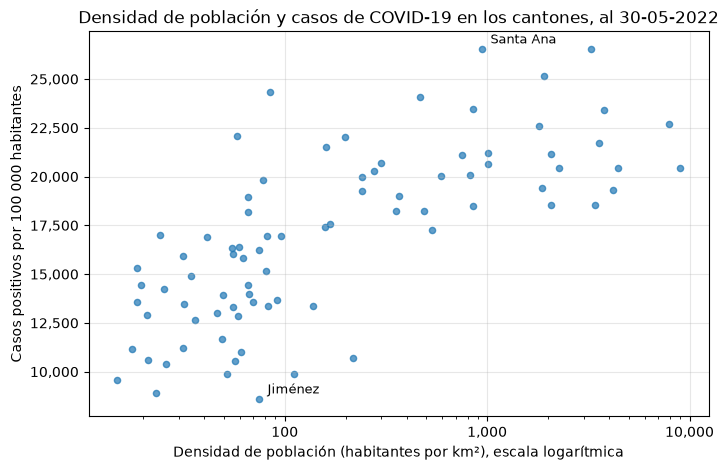

In [10]:
# Densidad de población y tasa de casos de COVID-19 por cantón
fig, ax = plt.subplots(figsize=(8, 5))

cantones_covid.plot(x="densidad", y="tasa_100k", kind="scatter", ax=ax, color=AZUL, alpha=0.7)

ax.set_title("Densidad de población y casos de COVID-19 en los cantones, al 30-05-2022")
ax.set_xlabel("Densidad de población (habitantes por km²), escala logarítmica")
ax.set_ylabel("Casos positivos por 100 000 habitantes")
ax.set_xscale("log")  # la densidad va de 6 a 8000: la escala logarítmica separa los valores pequeños
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.grid(alpha=0.3)

# Anotación de los cantones con la tasa más alta y la más baja
for indice in [cantones_covid["tasa_100k"].idxmax(), cantones_covid["tasa_100k"].idxmin()]:
    fila = cantones_covid.loc[indice]
    ax.annotate(fila["canton"], (fila["densidad"], fila["tasa_100k"]), xytext=(6, 4), textcoords="offset points", fontsize=9)

plt.show()

Hay una relación **positiva** clara: a mayor densidad, mayor tasa de casos registrados. Tres observaciones sobre el gráfico:

- La **escala logarítmica** del eje horizontal (`set_xscale("log")`) es la herramienta para variables muy asimétricas, como la densidad, que va de 6 habitantes por km² en Talamanca a casi 8000 en San José. En escala lineal, casi todos los puntos se amontonarían a la izquierda.
- `annotate()` etiqueta **algunos** puntos, los que ayudan a leer el gráfico; etiquetar los 82 lo volvería ilegible.
- Una relación en un gráfico no es una explicación. La densidad facilita el contagio, pero también coincide con más acceso a pruebas diagnósticas, que es lo que realmente se registra. El gráfico plantea la pregunta; no la responde.

## Varios gráficos en una figura

`plt.subplots()` acepta la cantidad de filas y de columnas de gráficos, y retorna un `Axes` por cada uno. Es la forma correcta de mostrar dos variables de **escalas distintas**, como la población y la densidad de las provincias: dos gráficos lado a lado, cada uno con su propio eje. (La alternativa, un solo gráfico con dos ejes verticales, es un error clásico de diseño: casi siempre confunde.)

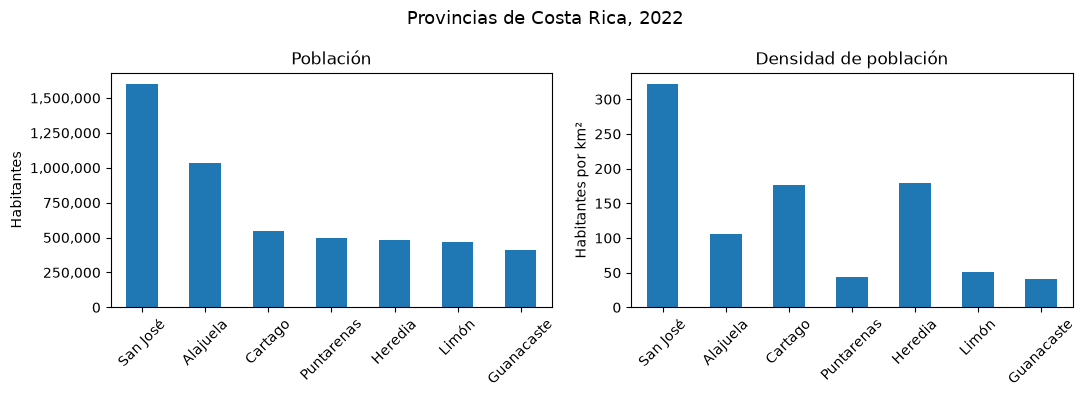

In [11]:
# Dos gráficos en una fila: población y densidad de las provincias
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(11, 4))

ordenadas = provincias.sort_values("poblacion", ascending=False)

ordenadas.plot(x="provincia", y="poblacion", kind="bar", ax=ax1, color=AZUL, legend=False)
ax1.set_title("Población")
ax1.set_xlabel("")
ax1.set_ylabel("Habitantes")
ax1.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

ordenadas.plot(x="provincia", y="densidad", kind="bar", ax=ax2, color=AZUL, legend=False)
ax2.set_title("Densidad de población")
ax2.set_xlabel("")
ax2.set_ylabel("Habitantes por km²")

for ax in (ax1, ax2):
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("Provincias de Costa Rica, 2022", fontsize=13)  # título de toda la figura
fig.tight_layout()  # ajusta los espacios para que nada se traslape

plt.show()

Con el mismo orden de las provincias en ambos gráficos se ve de inmediato que la relación entre población y densidad no es directa: Heredia, la quinta en población, es la segunda en densidad, y Guanacaste y Puntarenas, con poblaciones parecidas a las de Cartago y Heredia, tienen densidades mucho menores. El ciclo `for` aplica la misma configuración a los dos ejes: cualquier repetición en el código de un gráfico es candidata a un ciclo o a una función.

## Guardar una figura

El método `savefig()` de la figura la guarda en un archivo. La extensión determina el formato: PNG para documentos y páginas web, SVG o PDF para gráficos vectoriales que se pueden ampliar sin perder calidad. El argumento `dpi` es la resolución de los formatos de mapa de bits, y `bbox_inches="tight"` recorta los márgenes sobrantes:

In [12]:
# Guardado de la última figura en un archivo PNG
fig.savefig("provincias-poblacion-densidad.png", dpi=150, bbox_inches="tight")

El archivo se escribe en el directorio de trabajo del cuaderno: en Colab, aparece en el panel de archivos (ícono de carpeta, a la izquierda) y puede descargarse desde ahí; en VS Code, queda junto al archivo `.ipynb`. Un gráfico guardado así puede insertarse en un documento, en una presentación o en el `README.md` de un repositorio.

## Tablas para comunicar

Un DataFrame se despliega en el cuaderno con un formato pensado para explorar: todas las columnas, números sin separadores de miles y el índice numérico. Para presentar una tabla en un informe conviene seleccionar y ordenar las columnas y aplicar formato con el atributo `style`, cuyo método `format()` recibe un diccionario con el formato de cada columna (con la misma sintaxis de `StrMethodFormatter`), y `hide()` oculta el índice:

In [13]:
# Tabla de las provincias con formato para presentar
tabla = provincias[["provincia", "poblacion", "area_km2", "densidad"]].sort_values("poblacion", ascending=False)

tabla.style.format({
    "poblacion": "{:,.0f}",
    "area_km2": "{:,.1f}",
    "densidad": "{:,.1f}"
}).hide(axis="index")

provincia,poblacion,area_km2,densidad
San José,"1,601,167","4,969.8",322.2
Alajuela,"1,035,464","9,772.1",106.0
Cartago,"545,092","3,093.2",176.2
Puntarenas,"500,166","11,275.0",44.4
Heredia,"479,117","2,663.3",179.9
Limón,"470,383","9,176.9",51.3
Guanacaste,"412,808","10,196.3",40.5


El resultado de `style` es un objeto `Styler`, no un DataFrame: sirve para desplegar, no para seguir calculando. Como con los gráficos, la tabla se acompaña de una leyenda numerada y de un texto que diga qué muestra.

## Elegir el gráfico

El tipo de gráfico no se elige por gusto sino por la **pregunta** que debe responder y por el tipo de las variables. La tabla 1 resume los casos de este cuaderno.

<figure style="text-align: center; margin: 20px 0;">
    <figcaption><strong>Tabla 1</strong>. Tipo de gráfico según la pregunta. Elaboración propia, con base en Wilke (2019).</figcaption>
    <table class="table table-bordered table-striped" style="margin: 0 auto;">
    <thead>
        <tr><th>Pregunta</th><th>Variables</th><th>Gráfico</th><th><code>kind</code></th></tr>
    </thead>
    <tbody>
        <tr><td>¿Cómo se compara una magnitud entre categorías?</td><td>Una categórica y una numérica</td><td>Barras (horizontales si las categorías son muchas o tienen nombres largos)</td><td><code>"bar"</code>, <code>"barh"</code></td></tr>
        <tr><td>¿Cómo cambia una variable en el tiempo?</td><td>Tiempo y una numérica</td><td>Líneas</td><td><code>"line"</code></td></tr>
        <tr><td>¿Cómo se distribuye una variable?</td><td>Una numérica</td><td>Histograma</td><td><code>"hist"</code></td></tr>
        <tr><td>¿Se relacionan dos variables?</td><td>Dos numéricas</td><td>Dispersión</td><td><code>"scatter"</code></td></tr>
        <tr><td>¿Qué parte del total corresponde a cada categoría?</td><td>Una categórica y una numérica</td><td>Barras apiladas o barras ordenadas; el gráfico de pastel solo con muy pocas categorías</td><td><code>"bar"</code> con <code>stacked=True</code></td></tr>
    </tbody>
    </table>
</figure>

Y algunos errores de diseño frecuentes, que se reconocen con facilidad una vez nombrados:

- **Sin título, sin etiquetas o sin unidades**: el gráfico no se entiende fuera del cuaderno. Todo gráfico dice qué muestra, dónde y cuándo (título), y qué mide cada eje y en qué unidades (etiquetas).
- **Barras que no empiezan en cero**: la longitud de la barra deja de ser proporcional al valor y exagera las diferencias.
- **Gráficos de pastel** con muchas categorías o con valores parecidos: el ojo compara mal los ángulos; las barras ordenadas siempre se leen mejor.
- **Dos ejes verticales** en un mismo gráfico: la relación entre las dos series depende de cómo se escalen los ejes, y se puede hacer ver lo que se quiera. Dos gráficos lado a lado, como en la sección anterior.
- **Colores sin significado**: una barra de cada color cuando todas representan la misma variable. El color se usa para codificar algo (una serie, una categoría) o no se varía.
- **Categorías sin ordenar**: salvo que tengan un orden propio (años, meses), las categorías se ordenan por el valor, para que el gráfico se lea de un vistazo.

## Estructura de un cuaderno de análisis

Los cuadernos de las tareas y del proyecto final del curso combinan lo visto en las tres partes de la serie: pandas para procesar y matplotlib para graficar, con texto que explique. Un cuaderno de análisis de datos sigue, en general, esta estructura:

1. **Título e introducción**: el tema, la pregunta o preguntas que se quieren responder, la fuente de los datos (con su cita) y una descripción de las variables principales.
2. **Carga y preparación de los datos**: `read_csv()` o `read_excel()`, exploración inicial (`shape`, `info()`, `head()`), limpieza (llaves, tipos, valores faltantes) y las uniones o columnas nuevas que el análisis requiera.
3. **Resultados**: una o más tablas y varios gráficos. Cada uno responde una pregunta concreta, tiene título, etiquetas y unidades, y va acompañado de un párrafo que dice **qué muestra y qué se observa**. Un gráfico sin interpretación es un dato más, no un resultado.
4. **Conclusiones**: las respuestas a las preguntas de la introducción, con sus limitaciones.
5. **Referencias bibliográficas** de los datos y de las fuentes consultadas, en formato APA.

Este cuaderno tiene esa forma, salvo por las conclusiones: cada gráfico responde una pregunta y la interpreta. Es la estructura que se pide en la tarea 2, en la sección Evaluaciones del sitio del curso.

## Clínica de errores

Los problemas típicos de los gráficos, provocados a propósito. El primero no es un error de Python sino un gráfico ilegible: `plot()` sin `x` ni `y` dibuja todas las columnas numéricas como líneas, contra el índice de posiciones, que no significa nada:

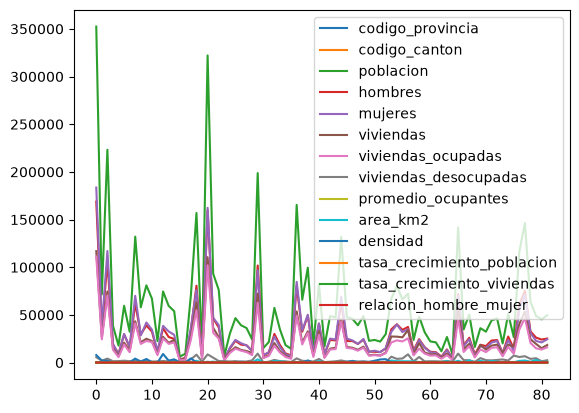

In [14]:
# Gráfico ilegible: todas las columnas numéricas, contra el índice, en líneas
cantones.plot()
plt.show()

TypeError: no numeric data to plot

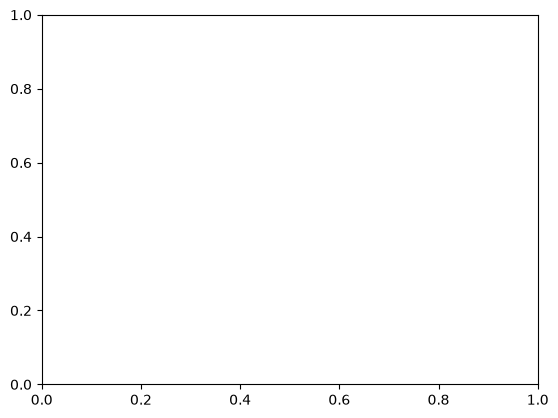

In [15]:
# TypeError: "no numeric data to plot"
# (las columnas seleccionadas son de texto; ¿cuál era la variable numérica?
# pandas alcanza a crear la figura antes de fallar, por eso aparece vacía)
cantones[["provincia", "canton"]].plot(kind="bar")

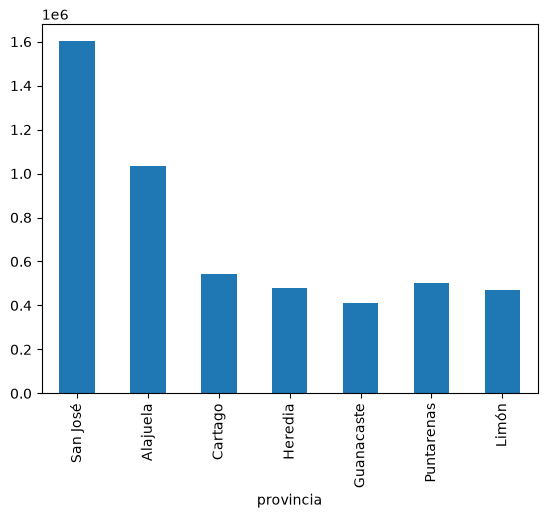

In [16]:
# Figura vacía: el título se aplicó a una figura nueva, no a la de la celda anterior
provincias.plot(x="provincia", y="poblacion", kind="bar", legend=False)
plt.show()

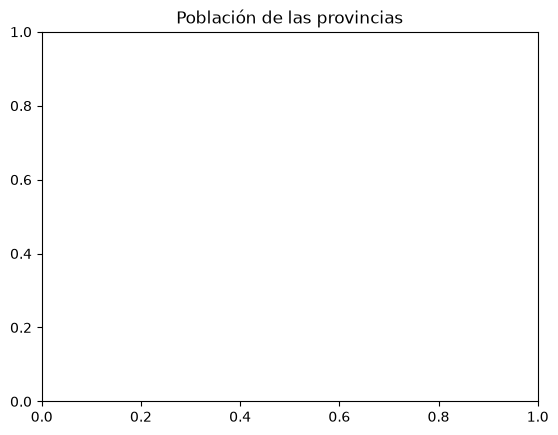

In [17]:
# Esta celda crea una figura nueva y vacía, con solo el título
plt.title("Población de las provincias")
plt.show()

El tercer caso es el más frecuente en los cuadernos de los estudiantes: una vez desplegada una figura, ya no se puede modificar desde otra celda. Todo el código de un gráfico, desde `subplots()` hasta `show()`, va en **una sola celda**.

## Asistentes de IA para generar gráficos

Los gráficos son un caso ideal para la generación de código con asistentes de IA, por dos razones. La primera es que matplotlib tiene una enorme cantidad de opciones (rotación de etiquetas, formatos de los ejes, posición de la leyenda, anotaciones) que nadie memoriza, y el asistente las conoce. La segunda es que la **verificación es visual**: el gráfico mismo muestra si el código hizo lo que se pidió. El prompt sigue la estructura de rol, contexto, tarea y formato de la parte II, y el contexto incluye, además de las columnas, el patrón de trabajo del curso:

> Actúe como asistente de visualización de datos con pandas y matplotlib **(rol)**. Tengo un DataFrame llamado `cantones` con una fila por cantón de Costa Rica y las columnas `provincia` (texto), `canton` (texto), `poblacion` (entero) y `densidad` (decimal, habitantes por km²) **(contexto)**. Escriba el código de un gráfico de barras horizontales con los diez cantones más densos, ordenados de mayor a menor, con título, etiquetas de los ejes con unidades y el valor al final de cada barra **(tarea)**. Use el patrón `fig, ax = plt.subplots()` y `plot(ax=ax)` de pandas, en una sola celda, con comentarios **(formato)**.

Las comprobaciones de la parte II se adaptan a los gráficos:

1. **Leer el código**: cada método que no se conozca se busca en la [documentación de matplotlib](https://matplotlib.org/stable/api/axes_api.html) o se pide al asistente que lo explique.
2. **Mirar el gráfico** con la lista de errores de diseño a mano: ¿tiene título, etiquetas y unidades?, ¿el orden es el pedido?, ¿el eje empieza en cero?
3. **Comparar con los datos**: los valores de las barras deben coincidir con los de la tabla (`sort_values("densidad", ascending=False).head(10)`).
4. **Preguntarse si responde la pregunta**: un gráfico correcto y bonito puede no ser el gráfico que el análisis necesita.

## Resumen

- Un gráfico sirve para **explorar** (rápido, sin refinar) y para **comunicar** (con título, etiquetas, unidades y orden). pandas dibuja con `plot()`; matplotlib refina.
- Toda figura de matplotlib tiene una **figura** (`Figure`) y uno o más **ejes** (`Axes`), con título, etiquetas, marcas, leyenda y cuadrícula. El patrón del curso: `fig, ax = plt.subplots()`, `df.plot(..., ax=ax)`, métodos `ax.set_*()`, `plt.show()`, todo en una celda.
- El tipo de gráfico depende de la **pregunta**: barras para comparar categorías, líneas para el cambio en el tiempo, histogramas para la distribución de una variable y dispersión para la relación entre dos.
- `StrMethodFormatter` da formato a las marcas de los ejes, `set_xscale("log")` sirve para variables muy asimétricas, `annotate()` etiqueta puntos seleccionados y `subplots(nrows, ncols)` produce varios gráficos en una figura.
- `savefig()` guarda la figura en PNG, SVG o PDF; `style.format()` da formato a una tabla para presentarla.
- Los errores de diseño más comunes: sin título o unidades, barras que no empiezan en cero, pasteles con muchas categorías, dos ejes verticales, colores sin significado y categorías sin ordenar.
- Un cuaderno de análisis tiene introducción, carga y preparación, resultados (tablas y gráficos con interpretación), conclusiones y referencias.

## Ejercicios

Los ejercicios se agrupan según la sección del cuaderno a la que corresponden; se recomienda realizarlos al concluir la sección respectiva. Resuélvalos en este mismo cuaderno (en su copia de Colab o local), después de ejecutar las celdas de las secciones anteriores. Varios incluyen una **celda de verificación** que examina la figura y los ejes creados: para que funcione, nombre las variables como se indica en el enunciado (por ejemplo, `fig_1` y `ax_1`) y ejecute la celda tal cual después de resolver el ejercicio (en la versión publicada muestra un recordatorio, porque los ejercicios no están resueltos). Las [soluciones de estos ejercicios](https://gf0657-programacionsig.github.io/2026-ii/soluciones-pandas-graficos-matplotlib) se publican después de la clase correspondiente.

### Barras

1. En una figura `fig_1` con ejes `ax_1`, grafique en barras horizontales los diez cantones con mayor **densidad** de población, ordenados con el más denso arriba, con título, etiqueta del eje horizontal con unidades y el valor al final de cada barra. ¿Cuántos de esos diez cantones están en la provincia de San José?

In [18]:
# Celda de verificación del ejercicio 1: ejecútela tal cual
try:
    assert len(ax_1.patches) == 10, "Deben graficarse exactamente 10 barras"
    assert ax_1.get_title() != "", "Falta el título"
    assert ax_1.get_xlabel() != "", "Falta la etiqueta del eje horizontal"
    assert ax_1.patches[-1].get_width() == max(p.get_width() for p in ax_1.patches), \
        "El cantón más denso debe quedar arriba: ordene de forma ascendente antes de graficar"
    print("Ejercicio 1: ¡correcto!")
except NameError:
    print("Aún no se han definido fig_1 y ax_1 (ejercicio 1).")

Aún no se han definido fig_1 y ax_1 (ejercicio 1).


2. En `fig_2` y `ax_2`, grafique en barras agrupadas las viviendas **ocupadas** y **desocupadas** de cada provincia, ordenadas por total de viviendas, con título, etiquetas y leyenda con nombres en español. ¿En cuál provincia es mayor la proporción de viviendas desocupadas? ¿Qué podría explicarlo?

In [19]:
# Celda de verificación del ejercicio 2: ejecútela tal cual
try:
    assert len(ax_2.patches) == 14, "Deben graficarse 14 barras: 2 series por cada una de las 7 provincias"
    assert ax_2.get_legend() is not None, "Falta la leyenda que distingue las dos series"
    assert ax_2.get_title() != "", "Falta el título"
    print("Ejercicio 2: ¡correcto!")
except NameError:
    print("Aún no se han definido fig_2 y ax_2 (ejercicio 2).")

Aún no se han definido fig_2 y ax_2 (ejercicio 2).


### Líneas e histogramas

3. En `fig_3` y `ax_3`, grafique en líneas la población de **hombres** y de **mujeres** en los censos de 1864 a 2022 (dos líneas en el mismo gráfico, con marcadores, leyenda y separador de miles en el eje vertical). ¿En qué censo se cruzan las dos líneas?

In [20]:
# Celda de verificación del ejercicio 3: ejecútela tal cual
try:
    assert len(ax_3.lines) == 2, "Deben graficarse dos líneas: hombres y mujeres"
    assert ax_3.get_legend() is not None, "Falta la leyenda"
    assert ax_3.get_title() != "", "Falta el título"
    print("Ejercicio 3: ¡correcto!")
except NameError:
    print("Aún no se han definido fig_3 y ax_3 (ejercicio 3).")

Aún no se han definido fig_3 y ax_3 (ejercicio 3).


4. En `fig_4` y `ax_4`, grafique el histograma de la **densidad** de población de los 82 cantones con 20 intervalos, con título y etiquetas. Describa la forma de la distribución en una celda de texto y compare el promedio y la mediana de la columna. Después pruebe con `bins=5` y `bins=80`: ¿qué se pierde en cada caso?

In [21]:
# Celda de verificación del ejercicio 4: ejecútela tal cual
try:
    assert len(ax_4.patches) == 20, "El histograma debe tener 20 intervalos (bins=20)"
    assert ax_4.get_xlabel() != "" and ax_4.get_ylabel() != "", "Faltan etiquetas de los ejes"
    print("Ejercicio 4: ¡correcto!")
except NameError:
    print("Aún no se han definido fig_4 y ax_4 (ejercicio 4).")

Aún no se han definido fig_4 y ax_4 (ejercicio 4).


### Dispersión y subgráficos

5. Agregue a `cantones` una columna `porcentaje_desocupadas` con el porcentaje de viviendas desocupadas respecto al total de viviendas. En `fig_5` y `ax_5`, grafique la relación entre la densidad de población (eje horizontal, en escala logarítmica) y ese porcentaje, y anote los dos cantones con mayor porcentaje. ¿Qué relación se observa? Proponga una explicación geográfica (piense en dónde están las viviendas de recreo).

In [22]:
# Celda de verificación del ejercicio 5: ejecútela tal cual
if "porcentaje_desocupadas" not in cantones.columns:
    print("Aún no se ha creado la columna porcentaje_desocupadas (ejercicio 5).")
else:
    try:
        assert cantones["porcentaje_desocupadas"].max() < 100, "El porcentaje debe estar entre 0 y 100"
        assert len(ax_5.collections) >= 1, "No hay un gráfico de dispersión en ax_5"
        assert ax_5.get_xscale() == "log", "El eje horizontal debe estar en escala logarítmica"
        print("Ejercicio 5: ¡correcto!")
    except NameError:
        print("Aún no se han definido fig_5 y ax_5 (ejercicio 5).")

Aún no se ha creado la columna porcentaje_desocupadas (ejercicio 5).


6. En una figura `fig_6` con **dos** gráficos lado a lado, muestre la tasa de crecimiento de la población (`tasa_crecimiento_poblacion`) y la tasa de crecimiento de las viviendas (`tasa_crecimiento_viviendas`) de las provincias, con el mismo orden en ambos, un título general y `tight_layout()`. ¿En todas las provincias crecen más rápido las viviendas que la población?

In [23]:
# Celda de verificación del ejercicio 6: ejecútela tal cual
try:
    assert len(fig_6.axes) == 2, "La figura debe tener exactamente dos gráficos"
    assert fig_6.get_suptitle() != "", "Falta el título general de la figura (suptitle)"
    print("Ejercicio 6: ¡correcto!")
except NameError:
    print("Aún no se ha definido fig_6 (ejercicio 6).")

Aún no se ha definido fig_6 (ejercicio 6).


### Guardar, tablas y diseño

7. Guarde la figura del ejercicio 6 en un archivo llamado `tasas-provincias.png` con 200 puntos por pulgada y márgenes recortados. Descárguelo y ábralo para verificar que se ve bien.

In [24]:
# Celda de verificación del ejercicio 7: ejecútela tal cual
import os
if os.path.exists("tasas-provincias.png"):
    print("Ejercicio 7: ¡correcto! El archivo existe.")
else:
    print("Aún no se ha guardado el archivo tasas-provincias.png (ejercicio 7).")

Aún no se ha guardado el archivo tasas-provincias.png (ejercicio 7).


8. Prepare para presentar una tabla con los cinco cantones con mayor tasa de casos de COVID-19 por 100 000 habitantes (`cantones_covid`): solo las columnas provincia, cantón, población, casos positivos y tasa, ordenadas de mayor a menor tasa, con separadores de miles, sin decimales y sin índice.

9. **Prediga antes de ejecutar**: ¿qué muestra el siguiente código? Escriba su predicción en una celda de texto y luego ejecútelo.

```python
cantones.plot(y="poblacion")
plt.show()
```

<details>
<summary>Después de ejecutar, haga clic aquí para ver la explicación</summary>

Sin <code>x</code>, pandas usa el índice del DataFrame, las posiciones de 0 a 81, como eje horizontal, y el tipo por defecto es <code>"line"</code>: se obtiene una línea que une la población de cantones consecutivos en el orden del archivo, cuyos picos son los cantones centrales de cada provincia. La línea sugiere una continuidad que no existe: los cantones son categorías. El gráfico correcto para comparar la población de los cantones es de barras (posiblemente solo de un subconjunto, porque 82 barras son demasiadas).

</details>

### Asistentes de IA

10. Pida a un asistente de IA el código del prompt de ejemplo de la sección de asistentes (los diez cantones más densos) y aplique las cuatro comprobaciones. Compare el gráfico con el del ejercicio 1: ¿son iguales?, ¿usó el mismo patrón?, ¿qué opciones de matplotlib usó que usted no conocía? Documente en una celda de texto el asistente, el prompt, el código y el resultado de las comprobaciones: es la **declaración de uso de IA** que piden los [lineamientos del curso](https://gf0657-programacionsig.github.io/2026-ii/asistentes-ia/).

11. Con los datos de su tarea 1, escriba en una celda de texto tres preguntas que se puedan responder con un gráfico y, para cada una, el tipo de gráfico que usaría y por qué, siguiendo la tabla 1. Es el punto de partida de la tarea 2.

## Referencias bibliográficas

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, *9*(3), 90-95. https://doi.org/10.1109/MCSE.2007.55
\
\
Instituto Nacional de Estadística y Censos. (2023). *Resultados Estimación de Población y Vivienda 2022* [Conjunto de datos]. INEC. https://admin.inec.cr/sites/default/files/2023-11/reResultadosEstimacionPoblacionVivienda2022_3.xlsx
\
\
McKinney, W. (2022). Plotting and visualization. En *Python for data analysis: Data wrangling with pandas, NumPy, and Jupyter* (3.ª ed.). O'Reilly Media. https://wesmckinney.com/book/plotting-and-visualization
\
\
Ministerio de Salud. (2022). *Situación Nacional COVID-19: casos positivos acumulados por cantón al 30 de mayo de 2022* [Conjunto de datos]. Ministerio de Salud de Costa Rica. https://github.com/gf0657-programacionsig/2026-ii/tree/main/datos/ministerio-salud
\
\
The Matplotlib Development Team. (s. f.). *Matplotlib documentation*. Recuperado el 26 de setiembre de 2026, de https://matplotlib.org/stable/
\
\
The pandas development team. (s. f.). Chart visualization. En *pandas documentation*. Recuperado el 26 de setiembre de 2026, de https://pandas.pydata.org/docs/user_guide/visualization.html
\
\
Wilke, C. O. (2019). *Fundamentals of data visualization: A primer on making informative and compelling figures*. O'Reilly Media. https://clauswilke.com/dataviz/